In [1]:
import os
import glob
import sqlite3
import pandas as pd

os.chdir("/Users/Yannick/Documents/PhD/text_mining/geothermal")

ANNOTATED_DIR = "annotation/databases"
all_db_paths = sorted(glob.glob(os.path.join(ANNOTATED_DIR, "*.db")))

def has_required_tables(db_path: str, required=("tasks", "annotations")) -> bool:
    con = sqlite3.connect(db_path)
    try:
        tables = pd.read_sql_query(
            "SELECT name FROM sqlite_master WHERE type='table'",
            con,
        )["name"].tolist()
    finally:
        con.close()
    return set(required).issubset(tables)

db_paths = [p for p in all_db_paths if has_required_tables(p)]

if len(db_paths) < 1:
    raise FileNotFoundError(
        f"Expected at least 1 valid annotation DB in {ANNOTATED_DIR}, found {len(db_paths)}: {db_paths}"
    )

print("Found valid DBs:")
for p in db_paths:
    print(" -", p)

def read_table(db_path: str, table: str) -> pd.DataFrame:
    con = sqlite3.connect(db_path)
    try:
        df = pd.read_sql_query(f"SELECT * FROM {table}", con)
    finally:
        con.close()
    df["source_db"] = os.path.basename(db_path)
    return df

# Read tasks from the first DB (they should be identical across annotators if seeded from same file)
tasks = read_table(db_paths[0], "tasks")

# Read and stack annotations from all DBs
annotations_list = [read_table(p, "annotations") for p in db_paths]
ann = pd.concat(annotations_list, ignore_index=True)

# Basic cleanup
for col in ["aspect_correct", "sentiment_correct"]:
    if col in ann.columns:
        ann[col] = pd.to_numeric(ann[col], errors="coerce")

# If duplicates exist (same sentence_id + annotator), keep the latest by created_at
if "created_at" in ann.columns:
    ann["created_at"] = pd.to_datetime(ann["created_at"], errors="coerce")

ann = ann.sort_values("created_at" if "created_at" in ann.columns else "sentence_id")
ann = ann.drop_duplicates(subset=["sentence_id", "annotator"], keep="last")

# Merge annotations with tasks to get predictions + text for analysis
df = ann.merge(tasks, on="sentence_id", how="left", suffixes=("", "_task"))

print("Merged dataset shape:", df.shape)
df.head()

Found valid DBs:
 - annotation/databases/annotations_fabien.db
 - annotation/databases/annotations_yannick.db
Merged dataset shape: (203, 16)


,sentence_id,annotator,sentiment_correct,matched_categories_present,matched_categories_correct,matched_categories_true,keywords_to_add,notes,created_at,source_db,sentence_text,aspect_pred,sentiment_pred,split_bucket,meta_json,source_db_task
0,000cb8f5b76249218f648b2bab5673a4,Egberink,1,0,0,Costs,boorkosten,None,2026-03-23 13:48:17.494517,annotations_yannick.db,"""Boorkosten zijn het grootste obstakel"", zegt ...",Boorkosten,Negative,9,"{""row_id"": 470, ""sentence_id"": 258, ""sentiment...",annotations_fabien.db
1,007030052dfe4e28ad232d265fe712e5,Egberink,1,1,1,None,None,None,2026-03-23 13:48:40.851639,annotations_yannick.db,Mocht de minister de vergunning toch willen ve...,minister,Negative,9,"{""row_id"": 1203, ""sentence_id"": 467, ""sentimen...",annotations_fabien.db
2,015d50a29d5c418d95c477131e8679a0,Egberink,1,0,1,None,None,None,2026-03-23 13:49:05.808092,annotations_yannick.db,Die lijn hield hij maandag vast.,lijn,Negative,7,"{""row_id"": 1066, ""sentence_id"": 749, ""sentimen...",annotations_fabien.db
3,01f9747d8ed5497b9cdcfe772ed5c903,Egberink,0,0,1,None,None,[Correct sentiment: Positive],2026-03-23 13:49:41.897711,annotations_yannick.db,Dat koude water warmt diep in de bodem langzaa...,water,Negative,19,"{""row_id"": 1912, ""sentence_id"": 35, ""sentiment...",annotations_fabien.db
4,028e35388c74472ca456ab5089524239,Egberink,1,1,1,None,None,None,2026-03-23 13:49:58.644848,annotations_yannick.db,de ogen van de operationeel directeur van Engi...,kosten,Positive,7,"{""row_id"": 1145, ""sentence_id"": 704, ""sentimen...",annotations_fabien.db


In [11]:
print("Annotators:", sorted(df["annotator"].dropna().unique().tolist()))
print("Keywords to add values:", sorted(df["keywords_to_add"].dropna().unique().tolist()))


# How many rows per annotator?
display(df.groupby("annotator")["sentence_id"].nunique().rename("n_annotated").to_frame())

# How many unique sentences annotated in total (across annotators)?
print("Unique sentence_ids annotated:", df["sentence_id"].nunique())
print("Total annotation rows:", len(df))

Annotators: ['Dekker', 'Egberink']
Keywords to add values: ['CO2', 'CO2-uitstoot', 'Mix', 'Onbetaalbaar', 'SodM', 'Verkoop', 'aardgasprijs', 'aardgasprijzen', 'ambitieus of twijfelachtig', 'bacteriën', 'beving', 'boorkosten', 'concurreren kostbaar', 'continu', 'duurzaam', 'duurzaamheid', 'duurzame', 'duurzame ', 'energierekening', 'failliet', 'financieringsbeleid', 'gasloos', 'geld', 'informatiebijeenkomst', 'informatiebijeenkomsten', 'investeerder', 'investeren, verdienen', 'jaarlasten', 'kansen', 'natuurlijk', 'natuurlijke wijze', 'onzekerheden;onzekerheid', 'overheid', 'prijs', 'regio of Friezen', 'schoon, schone', 'subsidie;subsidievrij', 'subsidies', 'veiligheid', 'verduurzamen', 'vertragingskosten', 'wethouder;raadsleden;gemeente', 'winst']


,n_annotated
annotator,
Dekker,103
Egberink,100


Unique sentence_ids annotated: 190
Total annotation rows: 203


In [3]:
import matplotlib.pyplot as plt

def plot_percent_bar(series: pd.Series, title: str, min_pct_to_show: float = 0.0):
    """
    Plots a simple bar chart of percentages for a categorical series.
    """
    s = series.dropna().astype(str)
    if s.empty:
        print(f"No data for: {title}")
        return

    counts = s.value_counts(dropna=False)
    pct = (counts / counts.sum()) * 100
    pct = pct[pct >= min_pct_to_show].sort_values(ascending=False)

    ax = pct.plot(kind="bar")
    ax.set_title(title)
    ax.set_ylabel("Percent (%)")
    ax.set_xlabel("")
    ax.set_ylim(0, max(5, pct.max() * 1.15))
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

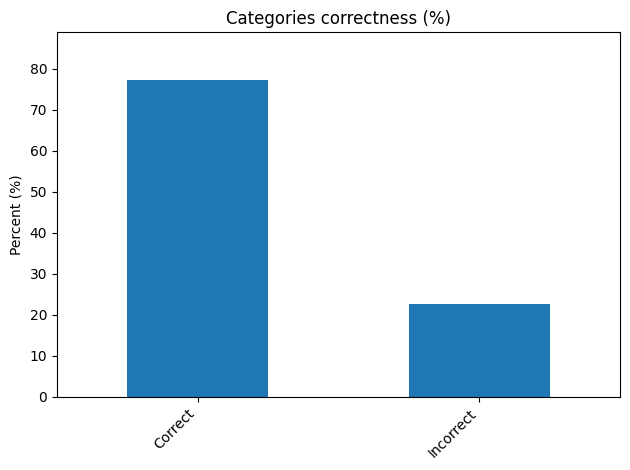

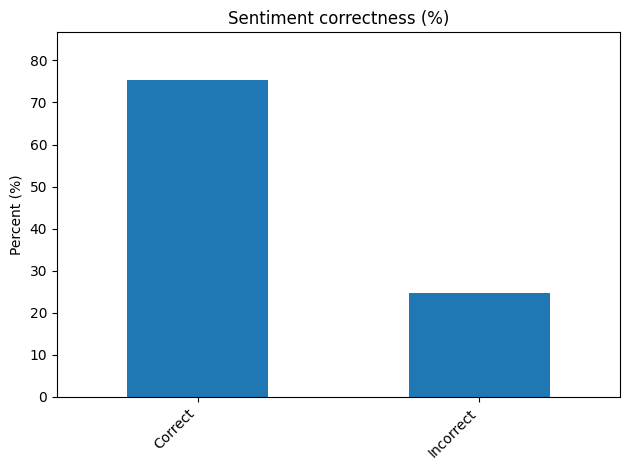

In [4]:
# Convert 0/1 -> labels for nicer charts
if "matched_categories_correct" in df.columns:
    plot_percent_bar(df["matched_categories_correct"].map({1: "Correct", 0: "Incorrect"}), "Categories correctness (%)")

if "sentiment_correct" in df.columns:
    plot_percent_bar(df["sentiment_correct"].map({1: "Correct", 0: "Incorrect"}), "Sentiment correctness (%)")

## Additional model-evaluation analyses

These cells are written to work with both the older annotation schema and the current `app.py` schema.
They focus on end-to-end quality, category coverage/error types, overlap agreement, and set-based category metrics.


In [5]:
import ast
import json
import re
import numpy as np


def parse_listish(value):
    if value is None or pd.isna(value):
        return []
    if isinstance(value, list):
        return [str(x).strip() for x in value if str(x).strip()]

    s = str(value).strip()
    if not s or s.lower() in {"nan", "none", "null"}:
        return []

    for parser in (json.loads, ast.literal_eval):
        try:
            parsed = parser(s)
            if isinstance(parsed, list):
                return [str(x).strip() for x in parsed if str(x).strip()]
        except Exception:
            pass

    return [part.strip() for part in s.split(";") if part.strip()]


def safe_meta_load(value):
    if value is None or pd.isna(value):
        return {}
    if isinstance(value, dict):
        return value
    try:
        return json.loads(value)
    except Exception:
        return {}


def extract_corrected_sentiment(row):
    if "sentiment_true" in row and pd.notna(row.get("sentiment_true")):
        return row.get("sentiment_true")

    notes = row.get("notes")
    if not isinstance(notes, str):
        return None

    match = re.search(r"\[Correct sentiment:\s*([^\]]+)\]", notes)
    return match.group(1).strip() if match else None


def get_predicted_categories(row):
    if "matched_categories_str" in row and pd.notna(row.get("matched_categories_str")):
        return parse_listish(row.get("matched_categories_str"))

    meta = safe_meta_load(row.get("meta_json"))
    return parse_listish(meta.get("matched_categories_str"))


def get_corrected_categories(row):
    if "matched_categories_correct" in row:
        if row.get("matched_categories_correct") == 1:
            return row.get("predicted_categories", [])
        return parse_listish(row.get("matched_categories_true"))

    if "category" in row and pd.notna(row.get("category")):
        return parse_listish(row.get("category"))

    return []


def classify_category_result(row):
    pred_set = set(row.get("predicted_categories", []))
    true_set = set(row.get("corrected_categories", []))

    if pred_set == true_set:
        return "Correct"
    if pred_set and not true_set:
        return "Wrongly identified category"
    if not pred_set and true_set:
        return "Wrongly no category found"
    if pred_set and true_set:
        return "Wrong category"
    return "Unclear"


def set_scores(pred, true):
    pred_set = set(pred)
    true_set = set(true)

    if not pred_set and not true_set:
        return pd.Series({
            "exact_match": 1.0,
            "jaccard": 1.0,
            "precision": 1.0,
            "recall": 1.0,
            "f1": 1.0,
        })

    inter = len(pred_set & true_set)
    union = len(pred_set | true_set)
    precision = inter / len(pred_set) if pred_set else 0.0
    recall = inter / len(true_set) if true_set else 0.0
    f1 = 0.0 if precision + recall == 0 else 2 * precision * recall / (precision + recall)

    return pd.Series({
        "exact_match": float(pred_set == true_set),
        "jaccard": inter / union if union else 1.0,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    })


def cohen_kappa(a, b):
    paired = pd.DataFrame({"a": a, "b": b}).dropna()
    if paired.empty:
        return np.nan

    labels = sorted(set(paired["a"]) | set(paired["b"]))
    conf = pd.crosstab(
        pd.Categorical(paired["a"], categories=labels),
        pd.Categorical(paired["b"], categories=labels),
        dropna=False,
    )

    n = conf.to_numpy().sum()
    if n == 0:
        return np.nan

    po = np.trace(conf.to_numpy()) / n
    row_marginals = conf.sum(axis=1).to_numpy() / n
    col_marginals = conf.sum(axis=0).to_numpy() / n
    pe = np.sum(row_marginals * col_marginals)

    if np.isclose(1 - pe, 0):
        return np.nan
    return (po - pe) / (1 - pe)


for col in ["sentiment_correct", "matched_categories_present", "matched_categories_correct", "aspect_correct"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

analysis_df = df.copy()
analysis_df["meta"] = analysis_df["meta_json"].apply(safe_meta_load) if "meta_json" in analysis_df.columns else [{} for _ in range(len(analysis_df))]
analysis_df["predicted_categories"] = analysis_df.apply(get_predicted_categories, axis=1)
analysis_df["corrected_categories"] = analysis_df.apply(get_corrected_categories, axis=1)
analysis_df["predicted_category_count"] = analysis_df["predicted_categories"].apply(len)
analysis_df["corrected_category_count"] = analysis_df["corrected_categories"].apply(len)
analysis_df["has_keyword_addition"] = analysis_df.get("keywords_to_add", pd.Series(index=analysis_df.index)).fillna("").astype(str).str.strip().ne("")
analysis_df["true_sentiment"] = analysis_df.apply(extract_corrected_sentiment, axis=1)
analysis_df["category_result_type"] = analysis_df.apply(classify_category_result, axis=1)
analysis_df["pipeline_correct"] = np.where(
    analysis_df.get("sentiment_correct", pd.Series(index=analysis_df.index)).eq(1)
    & analysis_df.get("matched_categories_correct", pd.Series(index=analysis_df.index)).eq(1),
    1,
    np.where(
        analysis_df.get("sentiment_correct", pd.Series(index=analysis_df.index)).notna()
        & analysis_df.get("matched_categories_correct", pd.Series(index=analysis_df.index)).notna(),
        0,
        np.nan,
    ),
)

category_score_cols = ["exact_match", "jaccard", "precision", "recall", "f1"]
analysis_df[category_score_cols] = analysis_df.apply(
    lambda row: set_scores(row["predicted_categories"], row["corrected_categories"]),
    axis=1,
)

print("Prepared analysis_df with columns:")
print(sorted([c for c in analysis_df.columns if c in {
    'sentiment_correct', 'matched_categories_present', 'matched_categories_correct',
    'predicted_categories', 'corrected_categories', 'true_sentiment', 'pipeline_correct',
    'exact_match', 'jaccard', 'precision', 'recall', 'f1', 'has_keyword_addition',
    'category_result_type'
}]))


Prepared analysis_df with columns:
['category_result_type', 'corrected_categories', 'exact_match', 'f1', 'has_keyword_addition', 'jaccard', 'matched_categories_correct', 'matched_categories_present', 'pipeline_correct', 'precision', 'predicted_categories', 'recall', 'sentiment_correct', 'true_sentiment']


In [6]:
summary_metrics = {
    "n_annotations": len(analysis_df),
    "n_unique_sentences": analysis_df["sentence_id"].nunique(),
}

if "sentiment_correct" in analysis_df.columns:
    summary_metrics["sentiment_accuracy"] = analysis_df["sentiment_correct"].mean()

if "matched_categories_correct" in analysis_df.columns:
    summary_metrics["category_accuracy"] = analysis_df["matched_categories_correct"].mean()

if "matched_categories_present" in analysis_df.columns:
    summary_metrics["category_coverage"] = analysis_df["matched_categories_present"].mean()

if analysis_df["pipeline_correct"].notna().any():
    summary_metrics["pipeline_accuracy"] = analysis_df["pipeline_correct"].mean()

if "keywords_to_add" in analysis_df.columns:
    summary_metrics["keyword_gap_rate"] = analysis_df["has_keyword_addition"].mean()

error_type_rates = (
    analysis_df["category_result_type"]
    .value_counts(normalize=True)
    .rename(lambda x: f"category_{str(x).lower().replace(' ', '_')}_rate")
)
summary_metrics.update(error_type_rates.to_dict())

display(
    pd.Series(summary_metrics)
    .to_frame("value")
    .assign(value=lambda x: x["value"].map(lambda v: round(v, 4) if isinstance(v, (int, float, np.floating)) else v))
)

coverage_breakdown = (
    analysis_df
    .groupby("category_result_type")
    .agg(
        n=("sentence_id", "count"),
        mean_jaccard=("jaccard", "mean"),
        keyword_gap_rate=("has_keyword_addition", "mean"),
    )
    .sort_values("n", ascending=False)
)
display(coverage_breakdown.round(4))


,value
n_annotations,203.0000
n_unique_sentences,190.0000
sentiment_accuracy,0.7537
category_accuracy,0.7734
category_coverage,0.0985
pipeline_accuracy,0.5567
keyword_gap_rate,0.2167
category_correct_rate,0.7734
category_wrongly_no_category_found_rate,0.2167
category_wrongly_identified_category_rate,0.0099


,n,mean_jaccard,keyword_gap_rate
category_result_type,,,
Correct,157,1.0,0.0
Wrongly no category found,44,0.0,1.0
Wrongly identified category,2,0.0,0.0


In [7]:
category_error_summary = (
    analysis_df["category_result_type"]
    .value_counts()
    .rename_axis("category_result_type")
    .to_frame("n")
)
category_error_summary["pct"] = category_error_summary["n"] / category_error_summary["n"].sum()
display(category_error_summary.round(4))

predicted_exploded = analysis_df[["sentence_id", "predicted_categories", "category_result_type", "jaccard"]].explode("predicted_categories")
predicted_exploded = predicted_exploded.dropna(subset=["predicted_categories"])

if not predicted_exploded.empty:
    predicted_profile = (
        predicted_exploded
        .groupby(["predicted_categories", "category_result_type"])
        .agg(
            n_predictions=("sentence_id", "count"),
            mean_jaccard=("jaccard", "mean"),
        )
        .reset_index()
        .sort_values(["n_predictions", "predicted_categories"], ascending=[False, True])
    )
    display(predicted_profile.head(20).round(4))

corrected_exploded = analysis_df[["sentence_id", "corrected_categories", "category_result_type"]].explode("corrected_categories")
corrected_exploded = corrected_exploded.dropna(subset=["corrected_categories"])

if not corrected_exploded.empty:
    corrected_profile = (
        corrected_exploded
        .groupby(["corrected_categories", "category_result_type"])
        .size()
        .rename("n")
        .reset_index()
        .sort_values("n", ascending=False)
    )
    display(corrected_profile.head(20))


,n,pct
category_result_type,,
Correct,157,0.7734
Wrongly no category found,44,0.2167
Wrongly identified category,2,0.0099


,predicted_categories,category_result_type,n_predictions,mean_jaccard
1,Costs,Correct,11,1.0
4,Risks,Correct,3,1.0
6,Sustainability,Correct,3,1.0
0,Comparing locations,Correct,1,1.0
2,Governance,Correct,1,1.0
3,Governance,Wrongly identified category,1,0.0
5,Support,Wrongly identified category,1,0.0


,corrected_categories,category_result_type,n
2,Costs,Wrongly no category found,18
10,Sustainability,Wrongly no category found,14
1,Costs,Correct,11
4,Governance,Wrongly no category found,5
7,Risks,Wrongly no category found,4
6,Risks,Correct,3
9,Sustainability,Correct,3
0,Comparing locations,Correct,1
3,Governance,Correct,1
5,Knowledge availability,Wrongly no category found,1


,mean_value
exact_match,0.7734
jaccard,0.7734
precision,0.7734
recall,0.7734
f1,0.7734


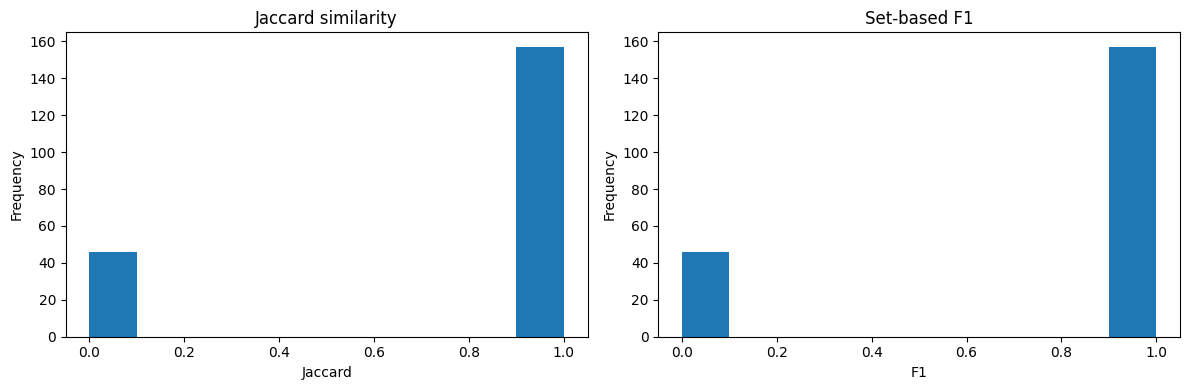

In [8]:
set_metric_summary = analysis_df[category_score_cols].mean().to_frame("mean_value")
display(set_metric_summary.round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
analysis_df["jaccard"].dropna().plot(kind="hist", bins=10, ax=axes[0], title="Jaccard similarity")
axes[0].set_xlabel("Jaccard")
analysis_df["f1"].dropna().plot(kind="hist", bins=10, ax=axes[1], title="Set-based F1")
axes[1].set_xlabel("F1")
plt.tight_layout()
plt.show()


In [9]:
if "annotator" in analysis_df.columns:
    overlap = analysis_df[analysis_df.duplicated("sentence_id", keep=False)].copy()
    print("Overlap rows:", len(overlap), "| Overlap sentence_ids:", overlap["sentence_id"].nunique())

    if not overlap.empty:
        sentiment_wide = overlap.pivot_table(index="sentence_id", columns="annotator", values="sentiment_correct", aggfunc="first")
        category_wide = overlap.pivot_table(index="sentence_id", columns="annotator", values="matched_categories_correct", aggfunc="first")
        coverage_wide = overlap.pivot_table(index="sentence_id", columns="annotator", values="matched_categories_present", aggfunc="first")

        agreement_rows = []
        for label, wide in {
            "sentiment_correct": sentiment_wide,
            "matched_categories_correct": category_wide,
            "matched_categories_present": coverage_wide,
        }.items():
            wide = wide.dropna()
            if wide.shape[1] >= 2 and not wide.empty:
                a = wide.iloc[:, 0]
                b = wide.iloc[:, 1]
                agreement_rows.append({
                    "metric": label,
                    "n_overlap_items": len(wide),
                    "raw_agreement": (a == b).mean(),
                    "cohen_kappa": cohen_kappa(a, b),
                })

        if agreement_rows:
            display(pd.DataFrame(agreement_rows).round(4))

        disagreement_audit = overlap.pivot_table(
            index="sentence_id",
            columns="annotator",
            values=["sentiment_correct", "matched_categories_present", "matched_categories_correct"],
            aggfunc="first",
        )
        disagreement_audit = disagreement_audit[disagreement_audit.nunique(axis=1) > 1]
        display(disagreement_audit.head(20))


Overlap rows: 26 | Overlap sentence_ids: 13


,metric,n_overlap_items,raw_agreement,cohen_kappa
0,sentiment_correct,13,1.0000,1.0
1,matched_categories_correct,13,0.8462,0.0
2,matched_categories_present,13,1.0000,NaN


matched_categories_correct           \
annotator                                            Dekker Egberink   
sentence_id                                                            
050d496185fe467c8358cf2f56f0dae4                          1        1   
089b7bd26c1d4e2d8b3ffe8ea8c28c7e                          1        1   
0e726dfbf10146b392bf47ca993019d5                          1        1   
1244c0081eca462a9c271d4bdef4a3ad                          1        1   
13e1e411f5fb40b4a7b0b920b9140a7e                          1        1   
1ae75e92302544e58806300d2abf6b00                          0        1   
1aee18463c354aafa799f782189b1e36                          1        1   
1d9c5aadab8241eeaef294e8c8f0fe9f                          1        1   
211e1c9b5ab34397be5f5edd0756a854                          1        1   
23a7934e618e4fdcb0fb7bc5af16febc                          1        1   
2787f555a9dd4f2caec193c1ce47672d                          1        1   
2d110660126f46f1aa69123bc128f974                          1        1   
2dc117dc4daf45f4aabfa1e1b7ee8a9e                          0        1   

                                 matched_categories_present           \
annotator                                            Dekker Egberink   
sentence_id                                                            
050d496185fe467c8358cf2f56f0dae4                          0        0   
089b7bd26c1d4e2d8b3ffe8ea8c28c7e                          0        0   
0e726dfbf10146b392bf47ca993019d5                          0        0   
1244c0081eca462a9c271d4bdef4a3ad                          0        0   
13e1e411f5fb40b4a7b0b920b9140a7e                          0        0   
1ae75e92302544e58806300d2abf6b00                          0        0   
1aee18463c354aafa799f782189b1e36                          0        0   
1d9c5aadab8241eeaef294e8c8f0fe9f                          0        0   
211e1c9b5ab34397be5f5edd0756a854                          0        0   
23a7934e618e4fdcb0fb7bc5af16febc                          0        0   
2787f555a9dd4f2caec193c1ce47672d                          0        0   
2d110660126f46f1aa69123bc128f974                          0        0   
2dc117dc4daf45f4aabfa1e1b7ee8a9e                          0        0   

                                 sentiment_correct           
annotator                                   Dekker Egberink  
sentence_id                                                  
050d496185fe467c8358cf2f56f0dae4                 1        1  
089b7bd26c1d4e2d8b3ffe8ea8c28c7e                 0        0  
0e726dfbf10146b392bf47ca993019d5                 1        1  
1244c0081eca462a9c271d4bdef4a3ad                 1        1  
13e1e411f5fb40b4a7b0b920b9140a7e                 1        1  
1ae75e92302544e58806300d2abf6b00                 1        1  
1aee18463c354aafa799f782189b1e36                 1        1  
1d9c5aadab8241eeaef294e8c8f0fe9f                 1        1  
211e1c9b5ab34397be5f5edd0756a854                 0        0  
23a7934e618e4fdcb0fb7bc5af16febc                 1        1  
2787f555a9dd4f2caec193c1ce47672d                 1        1  
2d110660126f46f1aa69123bc128f974                 1        1  
2dc117dc4daf45f4aabfa1e1b7ee8a9e                 1        1

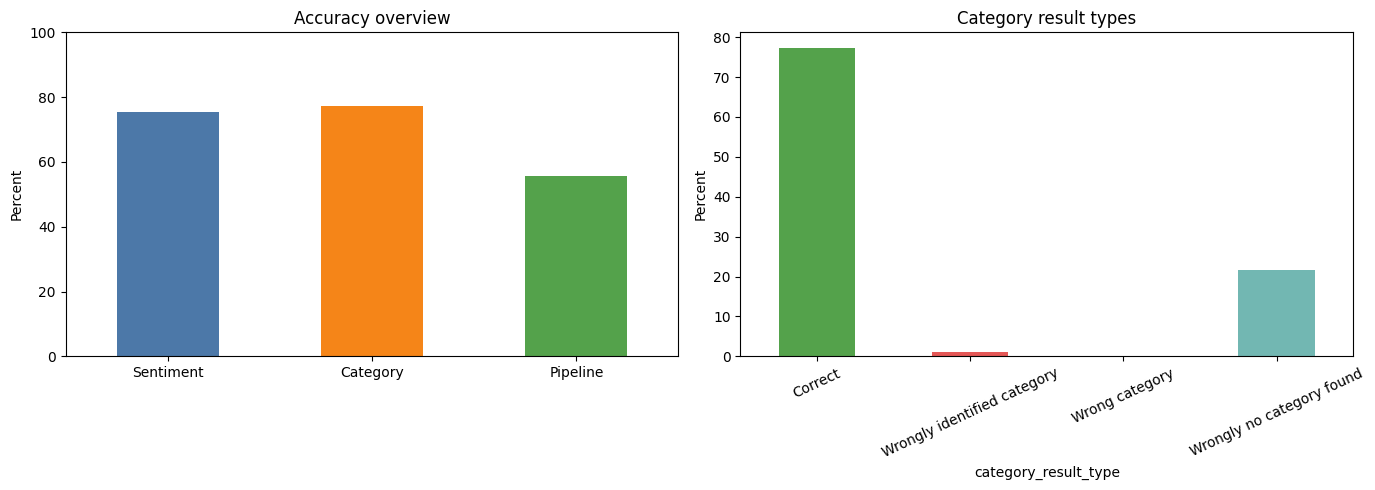

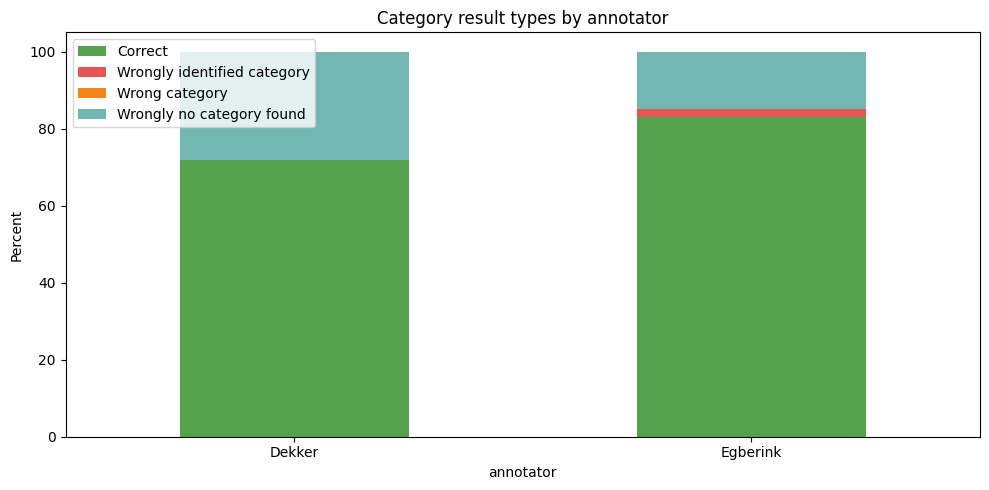

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metric_plot = pd.Series({
    "Sentiment": analysis_df["sentiment_correct"].mean() if "sentiment_correct" in analysis_df.columns else np.nan,
    "Category": analysis_df["matched_categories_correct"].mean() if "matched_categories_correct" in analysis_df.columns else np.nan,
    "Pipeline": analysis_df["pipeline_correct"].mean() if analysis_df["pipeline_correct"].notna().any() else np.nan,
}).dropna()
metric_plot.mul(100).plot(kind="bar", ax=axes[0], color=["#4C78A8", "#F58518", "#54A24B"])
axes[0].set_title("Accuracy overview")
axes[0].set_ylabel("Percent")
axes[0].set_ylim(0, 100)
axes[0].tick_params(axis="x", rotation=0)

error_order = [
    "Correct",
    "Wrongly identified category",
    "Wrong category",
    "Wrongly no category found",
]
error_counts = analysis_df["category_result_type"].value_counts().reindex(error_order, fill_value=0)
error_counts.mul(100 / error_counts.sum()).plot(kind="bar", ax=axes[1], color=["#54A24B", "#E45756", "#F58518", "#72B7B2"])
axes[1].set_title("Category result types")
axes[1].set_ylabel("Percent")
axes[1].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

if "annotator" in analysis_df.columns and analysis_df["annotator"].nunique() > 1:
    annotator_plot = (
        analysis_df
        .groupby(["annotator", "category_result_type"])
        .size()
        .unstack(fill_value=0)
        .reindex(columns=error_order, fill_value=0)
    )
    annotator_plot = annotator_plot.div(annotator_plot.sum(axis=1), axis=0) * 100
    annotator_plot.plot(kind="bar", stacked=True, figsize=(10, 5), color=["#54A24B", "#E45756", "#F58518", "#72B7B2"])
    plt.title("Category result types by annotator")
    plt.ylabel("Percent")
    plt.xticks(rotation=0)
    plt.legend(title="")
    plt.tight_layout()
    plt.show()
